# Experiment A-05 - NN Architecture Dependence  (more complex architecture)

## **🔴 Context**

- Until now, for the neural network only 2 hidden layers, a width of 32 and activation function tanh was used.
- More complex architectures could improve performance, but are computationally more expensive.

---

## **🟡 Experiment Questions**

#### **Q1 - Does more complex MLP architectures perform better?**

No, there is no significant differences in the performance of the different schemes.

#### **Q2 - How computationally expensive are more complex architectures?**

| H_ W__ | rel. H2 W32 (default) |
|------|---|
| H2 W64   | 2.3 x |
| H3 W64   | 3.4 x |
| H3 W128  | 12.1 x |

#### **Q3 - Does a different activation function yield better results?**

GELU achieves in total slightly better results than tanh.


---


## **🟢 Short Result**
#### No significant improvents through more complex architectures despite higher computational cost. gelu achieves slightly better results than tanh.


---

## **0. Setup**

In [1]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics

In [2]:
# Define experiment
EXP = "exp_A_04_nsteps";

## **1. Training**

In [3]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 900));

### 1.1. Shorter Trajectory

In [4]:
# Define experiment and schemes
SCHEMES = ["Steps1_Gap59", "Steps2_Gap58", "Steps5_Gap55"]
LABELS = ["S1 G59", "S2 G58", "S5 G55"]
COLORS = [JL_RED, JL_BLUE, JL_GREEN]
STEPS = 100:500;

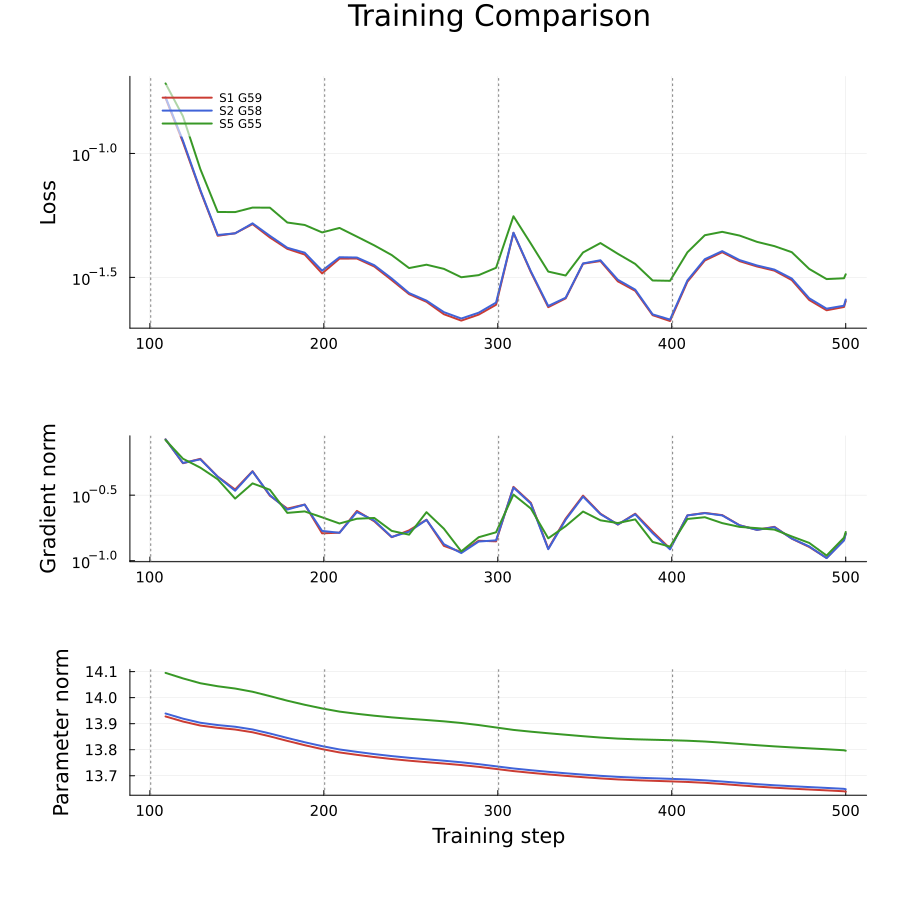

In [5]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

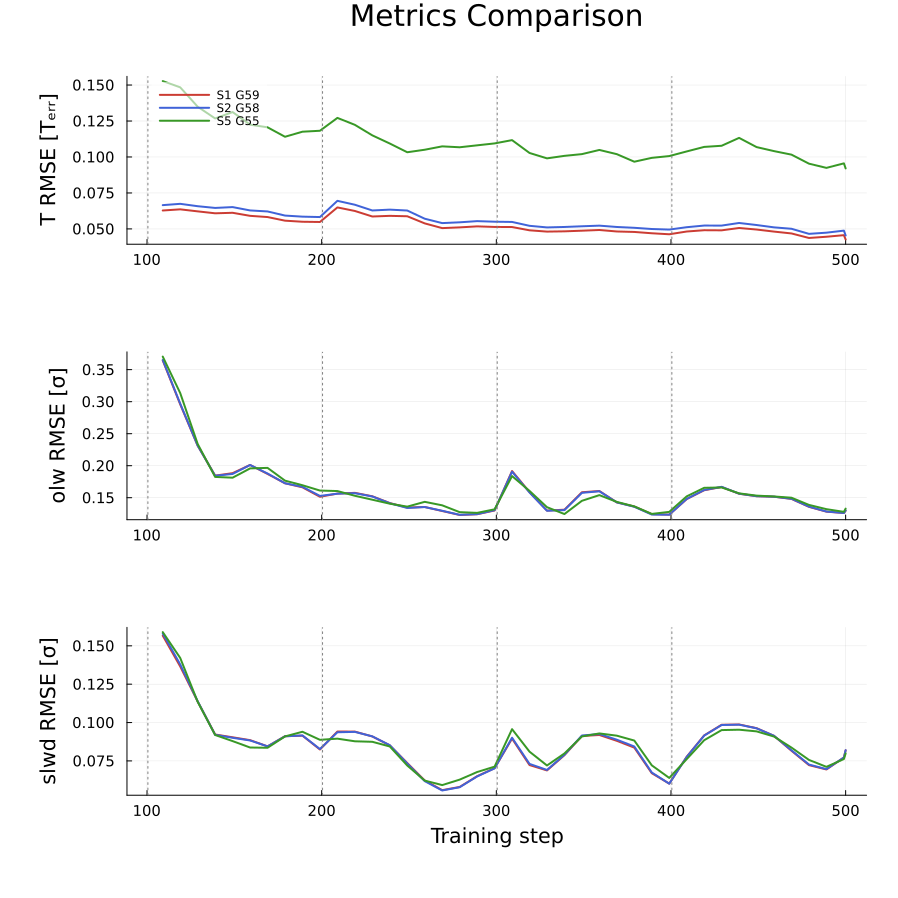

In [6]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

### 1.2. Longer Trajectory

In [7]:
# Define experiment and schemes
SCHEMES = ["Steps15_Gap45", "Steps20_Gap40", "Steps30_Gap30"]
LABELS = ["S15 G45", "S20 G40", "S30 G30"]
COLORS = [JL_RED, JL_BLUE, JL_GREEN]
STEPS = 100:500;

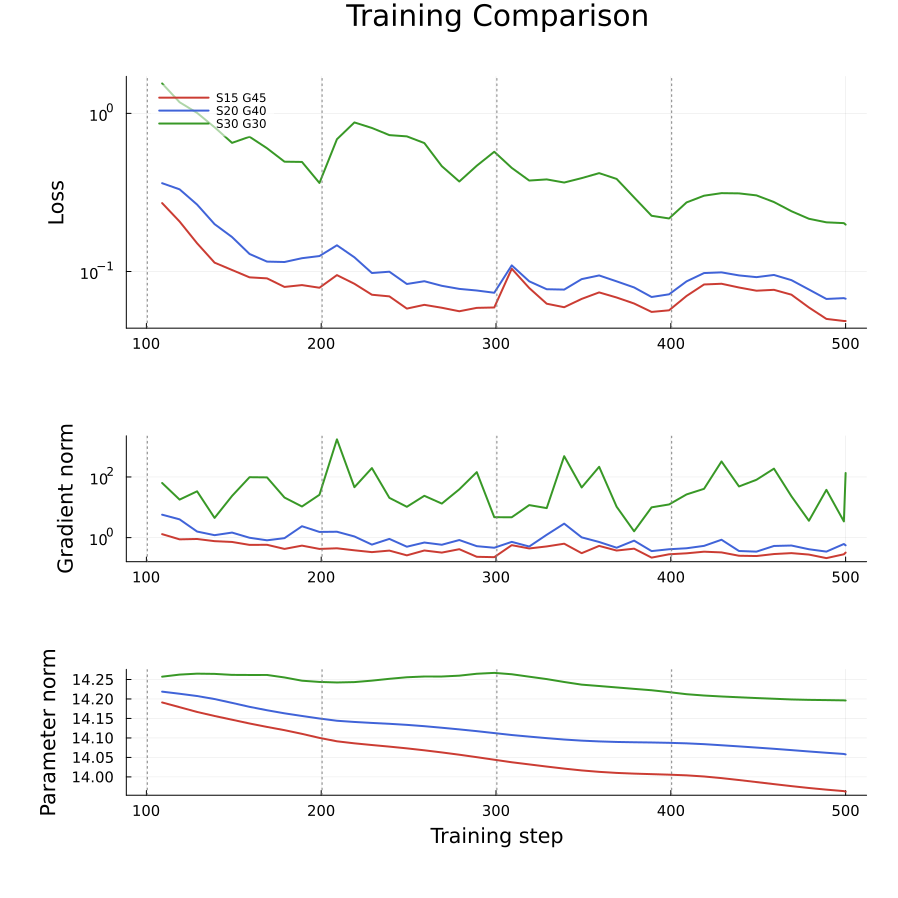

In [8]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

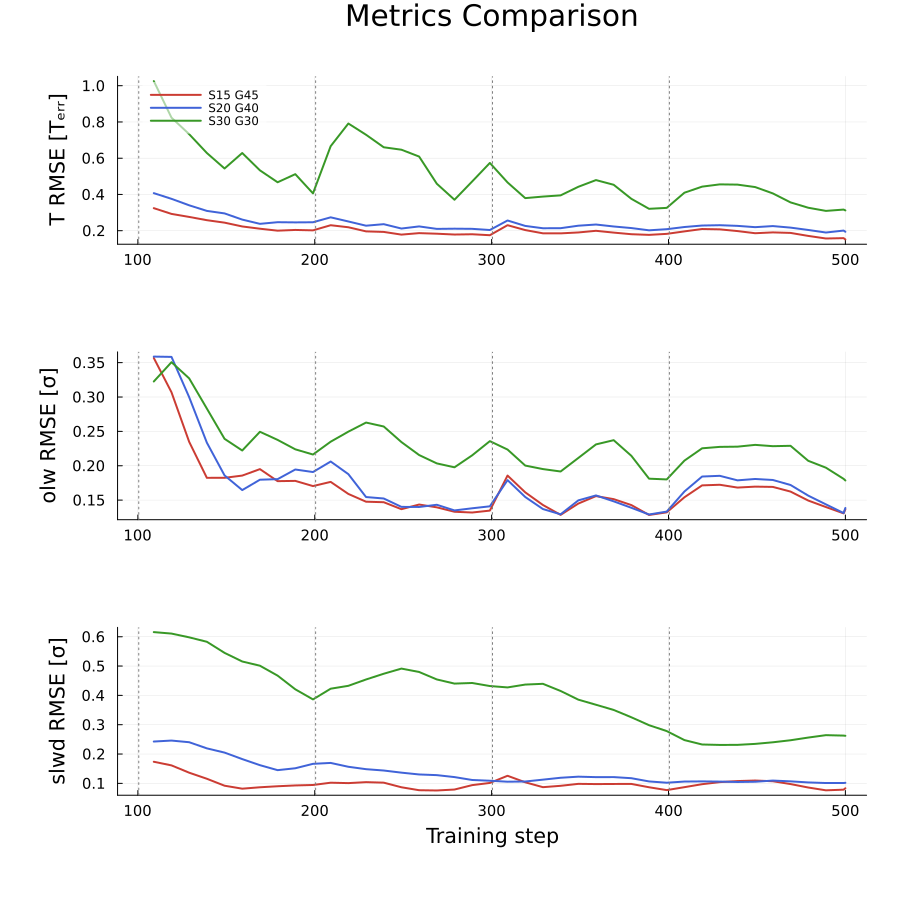

In [9]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [10]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

In [12]:
# Collect default scheme (H2 W32) rollouts
skill_default = collect_rollouts("exp_A_03_arch", ["NLW_H2_W32_skill"])
stab_default = collect_rollouts("exp_A_03_arch", ["NLW_H2_W32_stab"]);

### 2.1. Shorter Trajectory

In [13]:
# Load different architectures scheme rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "Steps1_Gap59_skill",
    "Steps2_Gap58_skill",
    "Steps5_Gap55_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill = merge(skill_default, collect_rollouts(EXP, SKILL_NAMES))
stab = merge(stab_default, collect_rollouts(EXP, STAB_NAMES))

LABELS = ["S10 G50 (default)", "OBLW", "S1 G59", "S2 G58", "S5 G55"]
COLORS = [:black, :grey, JL_BLUE, JL_GREEN, JL_RED];

#### 2.1.1. Skill (31 days)

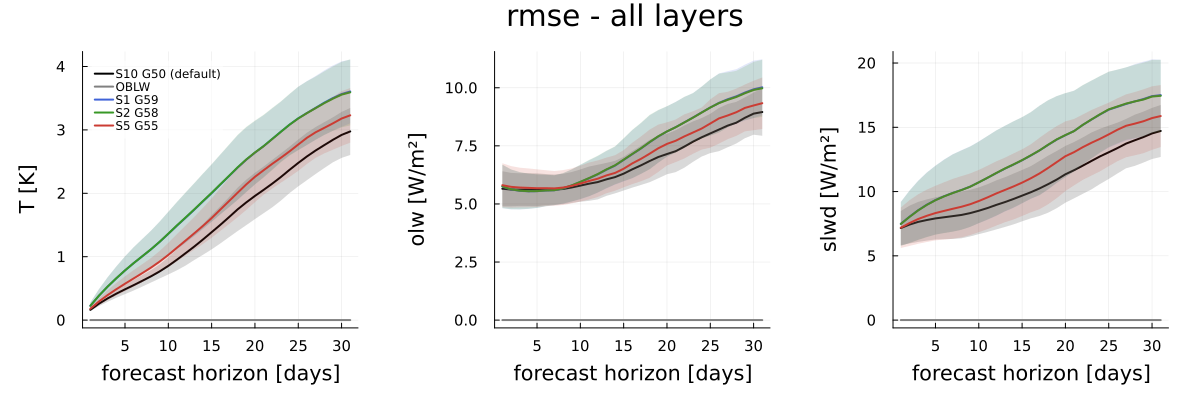

In [14]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

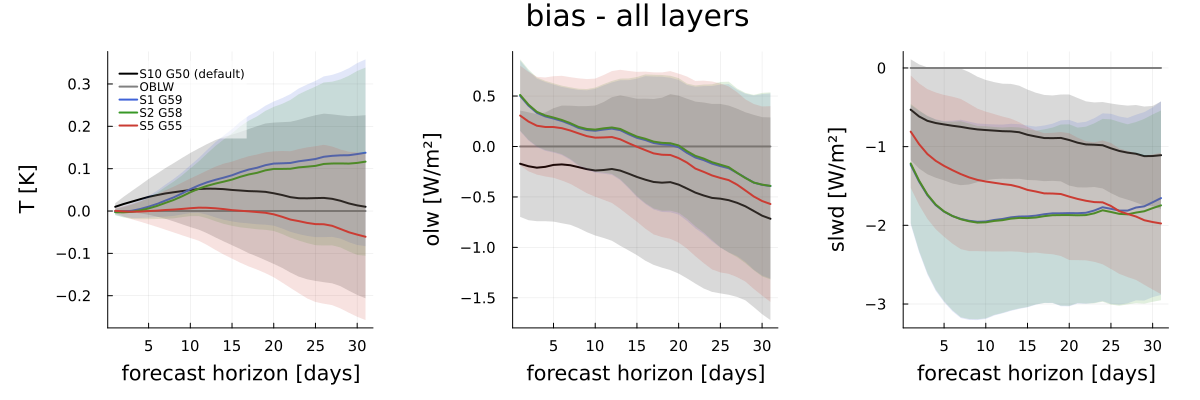

In [15]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

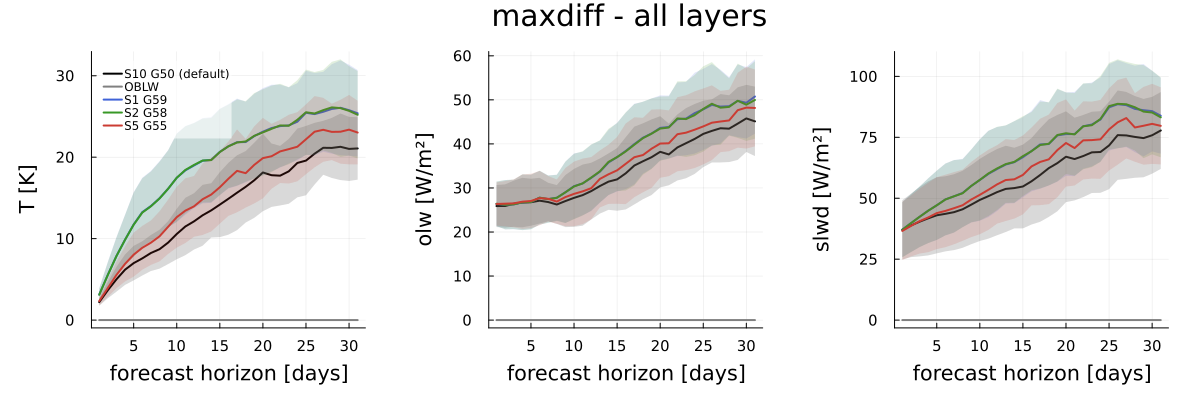

In [16]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

#### 2.1.2. Stability (365 days)

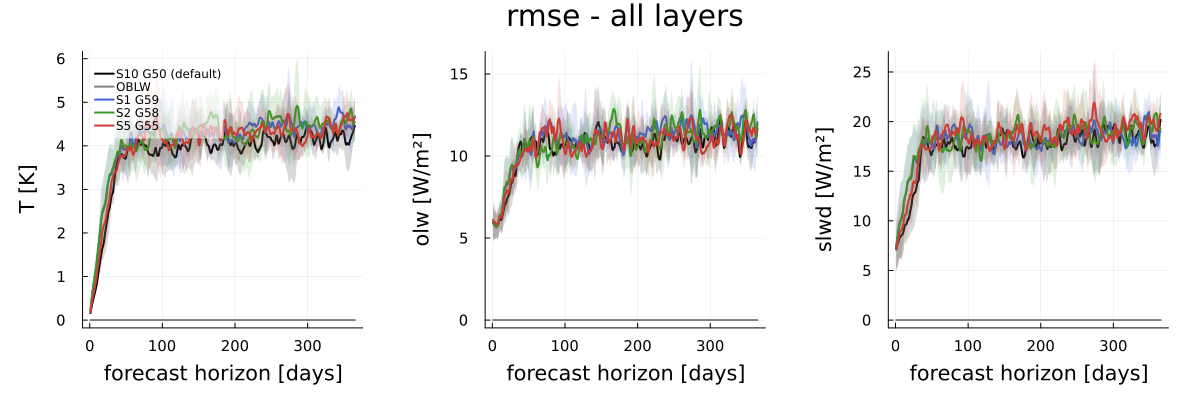

In [17]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

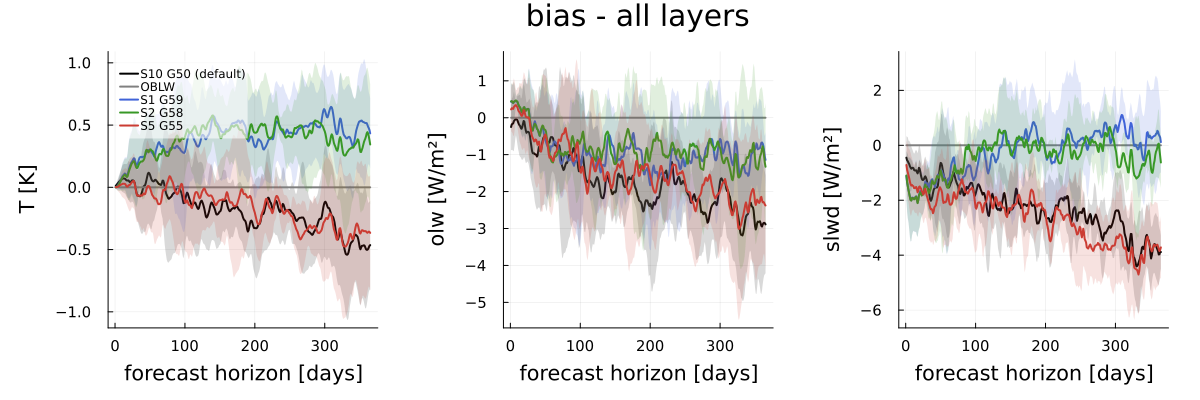

In [18]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

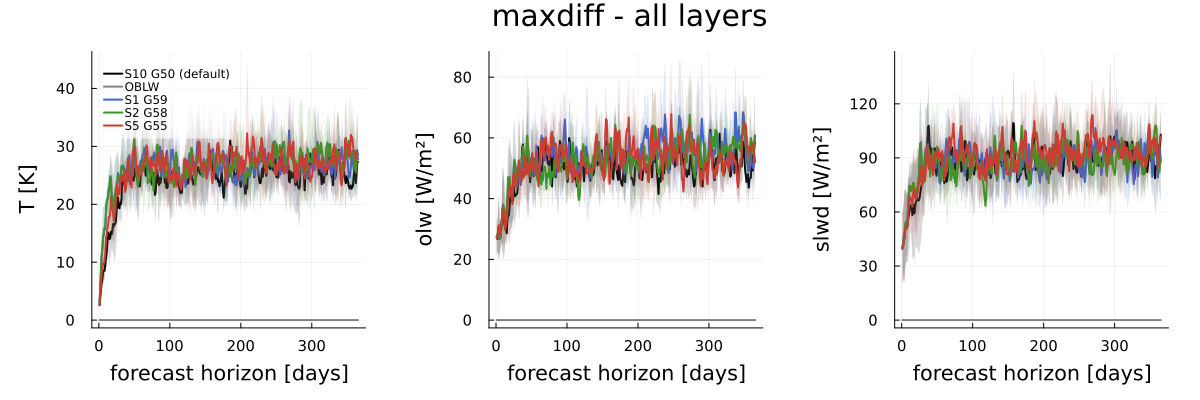

In [19]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

### 2.1. Longer Trajectory

In [21]:
# Load different architectures scheme rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "Steps15_Gap45_skill",
    "Steps20_Gap40_skill",
    "Steps30_Gap30_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill = merge(skill_default, collect_rollouts(EXP, SKILL_NAMES))
stab = merge(stab_default, collect_rollouts(EXP, STAB_NAMES))

LABELS = ["S10 G50 (default)", "OBLW", "S15 G45", "S20 G40", "S30 G30"]
COLORS = [:black, :grey, JL_BLUE, JL_GREEN, JL_RED];

#### 2.2.1. Skill (31 days)

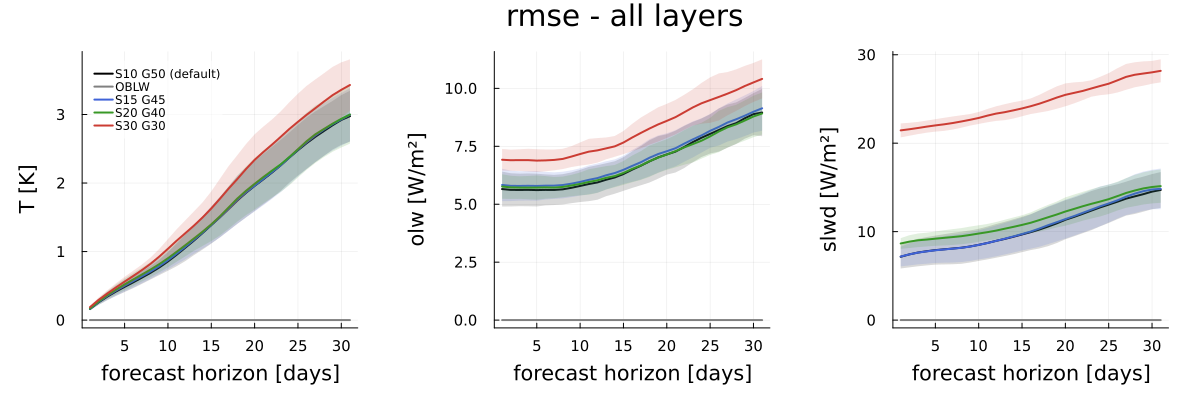

In [22]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

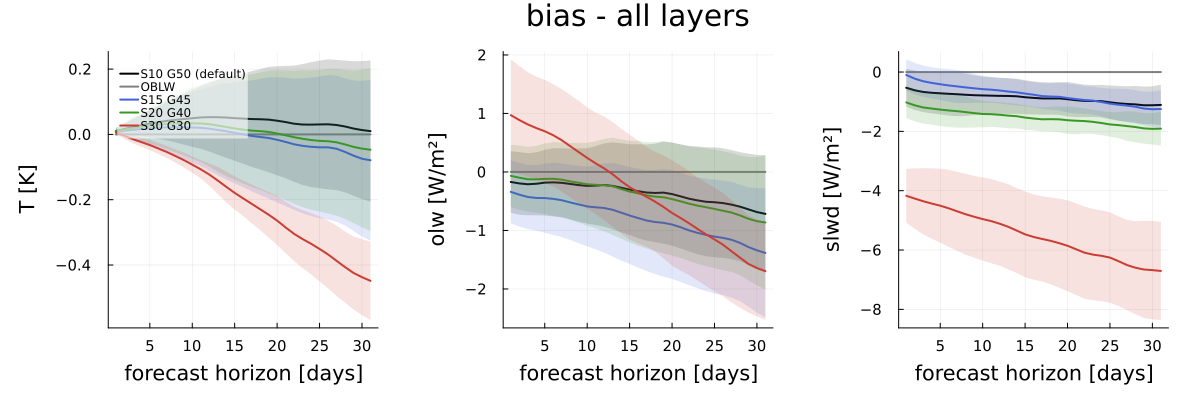

In [23]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

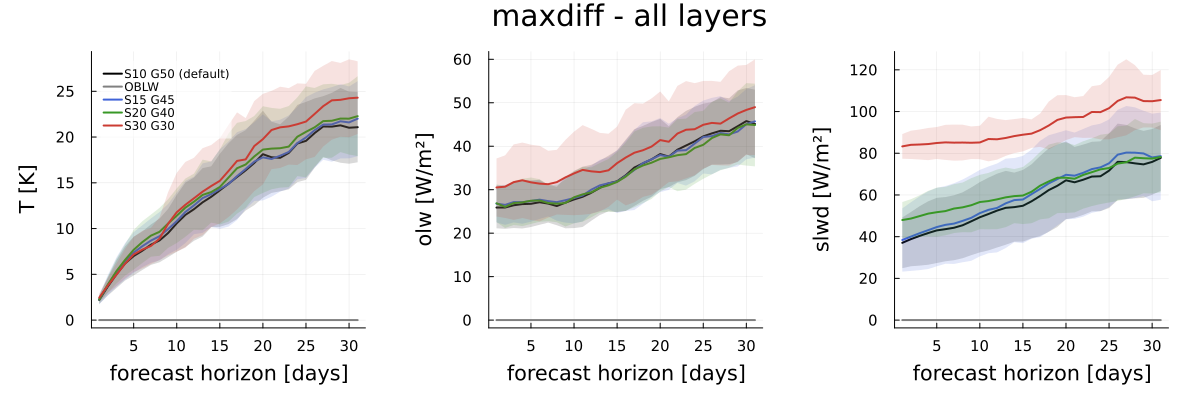

In [24]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

#### 2.2.2. Stability (365 days)

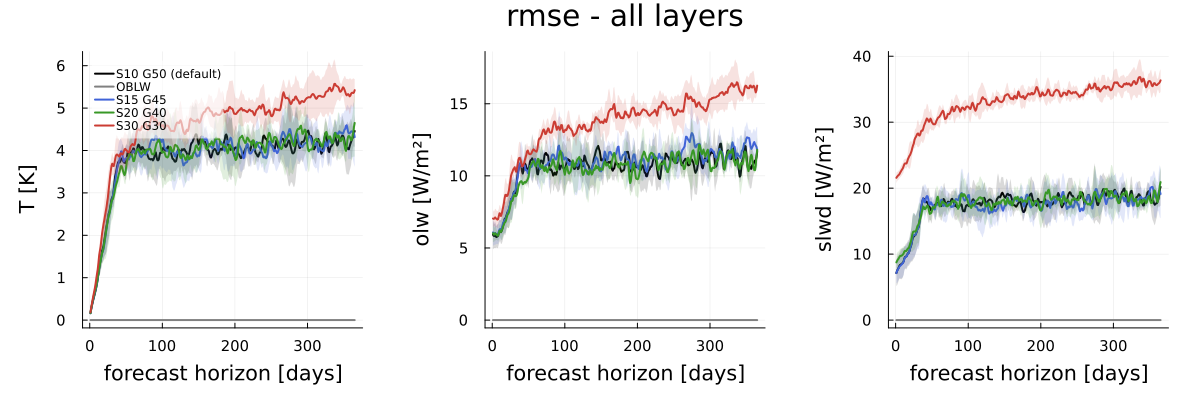

In [25]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

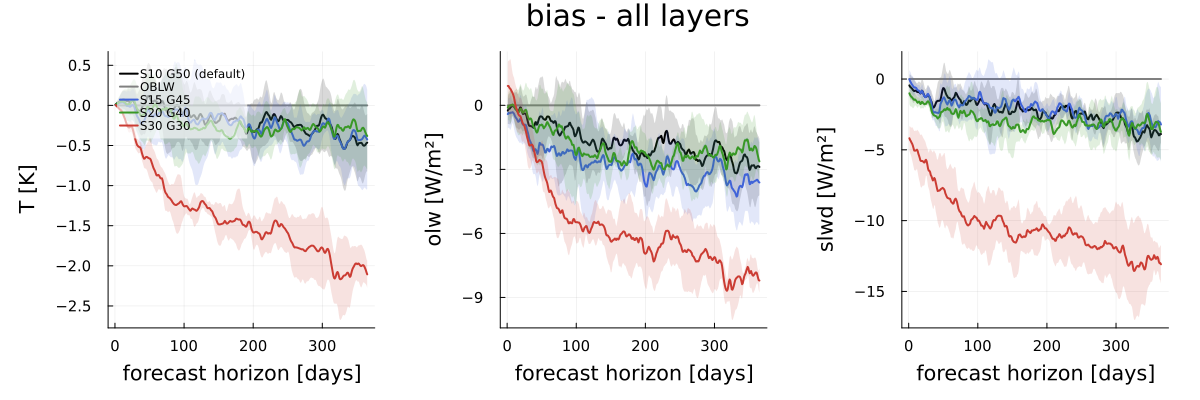

In [26]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

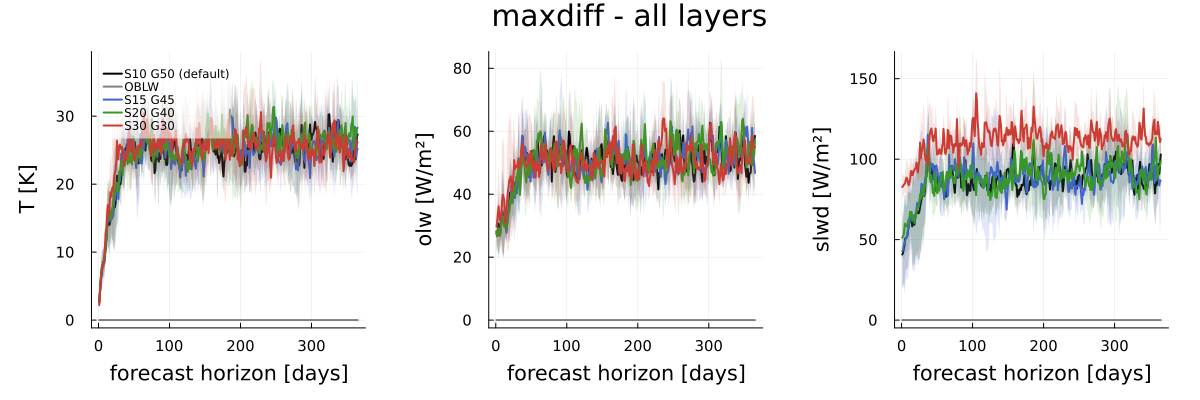

In [27]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)